**metingen** **7-9-2026**

Het plan was vandaag om eerst een beetje te kijken hoe onze metingen eruit zouden zien bij de verandering van massa. We hebben dus een kleine plot gemaakt om te zien of de metingen er een beetje logisch uitzagen. Als dat niet zo zou zijn zouden we misschien nog de instellingen van de oscilloscoop kunnen aanpassen of het zou natuurlijk kunnen, dat wat we gingen meten gewoon niet klopte. Aan de "oefen" grafiek te zien, ging het allemaal goed en zijn we door gegaan naar echte metingen uitvoeren.

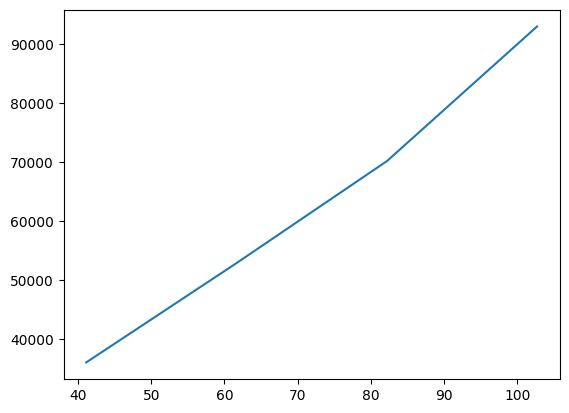

In [52]:
#metingen 7-9-2026

import matplotlib.pyplot as plt
import numpy as np
#ff kijken hoe zo'n grafiek er uit zou zien
#array voor spanning en grondtoon (boventonen), bij spanningsverandering, oefenmetingen, met oog afgelezenv
T= np.array([102.7,82.2,61.6,41.1])
f_1= np.array([305.0,265.0,230.0,190.0])


plt.figure()
plt.plot(T,f_1**2)
plt.show()

We hebben nu de lengte van de snaar opgemeten: 31.5 cm, de gewichten die we gingen gebruiken gewogen, de kleine weegt hier m=0.5253 kg en de grote weegt m=0.10468 kg. 

We wisten nog niet zo goed hoe we de massadichtheid moesten berekenen. Als eerst hebben we online de dichtheid van rvs opgezocht: 8000 $kg/m^3$ en hebben we de diameter van de snaar opgemeten: 0.80 mm. We kwamen uit op een massadichteid van 0.004 kg/m. Alleen wisten de TA's niet zeker of de snaar wel van rsv was gemaakt. Dus hebben de lengte van de snaar opgemeten: 59 cm en de snaar gewogen: 1.9 g. Toen kwamen we uit op een massadichtheid van 0.0032 kg/m. Deze hebben we meegenomen in al onze berekeningen. 

De spanning bleek best wel makkelijk te berekenen. Op de arm staat namelijk 1:10-4. Dus bij de buitenste ophangplaats voor gewichten is de spanning 10 keer groter dan de zwaartekracht op het gewicht. T is dus berekend met T=mg*constante. constante is dus 10,8,6,4.

We hebben metingen gedaan met 11 verschillende waardes voor T.

Hieronder staat het resultaat van onze metingen.

mu = 0.003220 ± 0.000085 kg/m
a = 774.90 ± 24.36


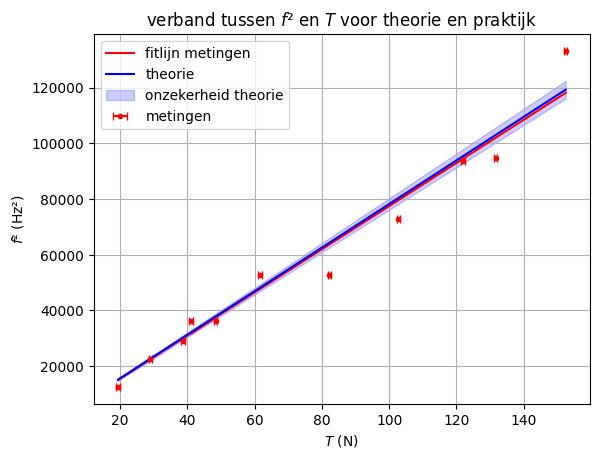

Gemiddelde residu: -550.65
Standaarddeviatie residuen: 7007.91


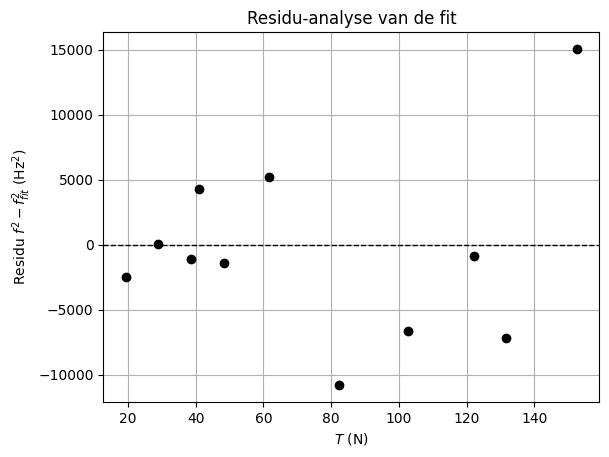

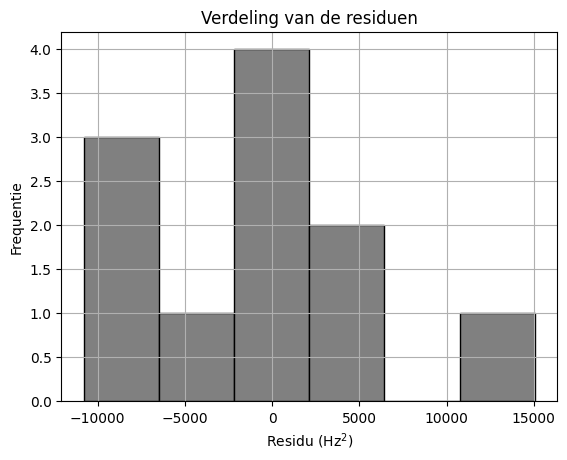

R² = 0.9639
a_theorie = 782.38 ± 20.75
a_fit     = 774.90 ± 24.36
Verschil tussen a_fit en a_theorie: 7.48
Gecombineerde onzekerheid: 32.00
De twee waarden komen overeen binnen de meetonzekerheid.


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- gegeven waarden en fouten ---
L = 0.315          # m
sigma_L = 0.0005   # m  (0.05 cm)

m_snaar = 0.0019        # kg  (1.9 g)
sigma_m_snaar = 0.00005 # kg  (0.05 g)
L_snaar = 0.59          # m
sigma_L_snaar = 0.0005  # m  (0.05 cm)

mu = m_snaar / L_snaar
sigma_mu = mu * np.sqrt((sigma_m_snaar/m_snaar)**2 + (sigma_L_snaar/L_snaar)**2)
print(f"mu = {mu:.6f} ± {sigma_mu:.6f} kg/m")

g = 9.81
sigma_m = 0.05      # kg, meetfout op de massa waarmee T bepaald is
constante = 1       # <-- pas aan als jullie een andere factor gebruikten

# fout op T: T = m*g*constante  ->  sigma_T = g*constante*sigma_m
sigma_T = g * constante * sigma_m   # zelfde absolute fout voor elk punt

T_m = np.array([152.5,131.7,122.0,102.7,82.2,61.6,41.1,48.4,38.7,29.0,19.4])
f_g = np.array([365.0,308.0,306.0,270.0,230.0,230.0,190.0,190.0,170.0,150.0,112.0])

def lineair(x, a):      # let op: x moet eerst, anders klopt curve_fit niet
    return a * x

x = T_m
y = f_g**2

popt, pcov = curve_fit(lineair, x, y)
a = popt[0]
a_err = np.sqrt(pcov[0,0])
print(f"a = {a:.2f} ± {a_err:.2f}")

T_theorie = np.linspace(min(T_m), max(T_m), 200)

def i_snaartheorie(T):
    return 1/(4*L**2) * T/mu

y_theorie = i_snaartheorie(T_theorie)

# onzekerheidsband op de theoretische lijn via foutvoortplanting
rel_fout = np.sqrt((2*sigma_L/L)**2 + (sigma_mu/mu)**2)
y_theorie_fout = y_theorie * rel_fout

plt.figure()
plt.errorbar(T_m, f_g**2, xerr=sigma_T, fmt='r.', capsize=3, label='metingen')
plt.plot(T_m, lineair(T_m, a), 'r-', label='fitlijn metingen')
plt.plot(T_theorie, y_theorie, 'b-', label='theorie')
plt.fill_between(T_theorie, y_theorie - y_theorie_fout, y_theorie + y_theorie_fout,
                  color='blue', alpha=0.2, label='onzekerheid theorie')
plt.xlabel("$T$ (N)")
plt.ylabel('$f²$ (Hz²)')
plt.legend()
plt.grid()
plt.title("verband tussen $f²$ en $T$ voor theorie en praktijk")
plt.savefig("verbandTenf.png")
plt.show()

# --- Residu-analyse ---
y_pred = a * T_m
residuen = f_g**2 - y_pred   # verschil tussen meting en fit

# Basisstatistieken van de residuen
print(f"Gemiddelde residu: {np.mean(residuen):.2f}")
print(f"Standaarddeviatie residuen: {np.std(residuen, ddof=1):.2f}")

# Residuen tegen T (checken op patronen)
plt.figure()
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.plot(T_m, residuen, 'ko', markersize=6)
plt.xlabel("$T$ (N)")
plt.ylabel("Residu $f^2 - f^2_{fit}$ (Hz$^2$)")
plt.title("Residu-analyse van de fit")
plt.grid()
plt.savefig('residugrafiekfenT.png')
plt.show()

# Histogram van de residuen (check op normale verdeling)
plt.figure()
plt.hist(residuen, bins=6, color='gray', edgecolor='black')
plt.xlabel("Residu (Hz$^2$)")
plt.ylabel("Frequentie")
plt.title("Verdeling van de residuen")
plt.grid()
plt.show()


y_gemiddeld = np.mean(f_g**2)
SS_res = np.sum((f_g**2 - y_pred)**2)
SS_tot = np.sum((f_g**2 - y_gemiddeld)**2)
R2 = 1 - SS_res/SS_tot
print(f"R² = {R2:.4f}")

# --- Meetfout op de theoretische coëfficiënt a_theorie = 1/(4*L^2*mu) ---

a_theorie = 1 / (4 * L**2 * mu)

# relatieve fout via foutenvoortplanting (L^2 geeft factor 2, mu^1 geeft factor 1)
rel_fout_a_theorie = np.sqrt((2 * sigma_L / L)**2 + (sigma_mu / mu)**2)
sigma_a_theorie = a_theorie * rel_fout_a_theorie

print(f"a_theorie = {a_theorie:.2f} ± {sigma_a_theorie:.2f}")

# --- Vergelijking met de gefitte waarde ---
print(f"a_fit     = {a:.2f} ± {a_err:.2f}")

verschil = abs(a - a_theorie)
gecombineerde_fout = np.sqrt(a_err**2 + sigma_a_theorie**2)
print(f"Verschil tussen a_fit en a_theorie: {verschil:.2f}")
print(f"Gecombineerde onzekerheid: {gecombineerde_fout:.2f}")

if verschil < gecombineerde_fout:
    print("De twee waarden komen overeen binnen de meetonzekerheid.")
else:
    print(f"De twee waarden verschillen met {verschil/gecombineerde_fout:.1f} keer de gecombineerde onzekerheid — mogelijk systematische afwijking.")

De $R^2$ waarde voor deze metingen is acceptabel. We kunnen deze metingen dus gebruiken om de onderzoeksvraag te beantwoorden. Na deze metingen hadden we nog tijd over, dus gingen we kijken wat we nog meer konden meten om onze onderzoeksvraag te beantwoorden. Het plan was om bij verschillende amplitudes de frequentie te meten. Volgens de theorie zou deze constant blijven. 

We zoeken dus de grondtoon op van de opstelling met constante L en T. De spanning bij deze metingen was T=102.7 N. Dan veranderen we op de functiegenerator de amplitude. We kunnen tussen 1 - 10 Vpp zitten. ALs we groter dan dat gaan branden de kabels kennelijk door. We zijn dus wel gelimiteerd met de meetpunten die we kunnen hebben.



566.9227346522165 Hz
Vpp, gemiddelde f, fout:
  1  488.0 ± 0.0 Hz
  3  488.7 ± 0.7 Hz
  5  564.7 ± 20.3 Hz
  7  577.7 ± 2.4 Hz
  9  571.7 ± 5.8 Hz
 10  565.0 ± 4.0 Hz


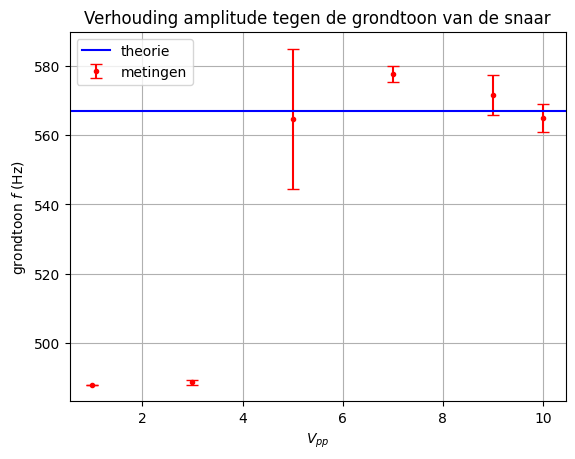

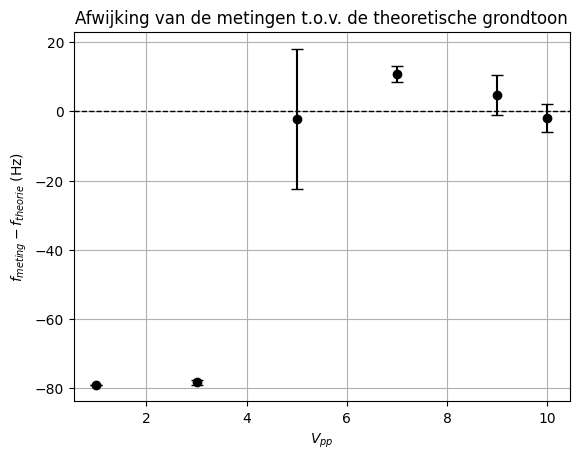

Gemiddelde afwijking: -24.311623541105394
Standaarddeviatie afwijking: 42.315963190511674


In [54]:
import numpy as np
import matplotlib.pyplot as plt

# --- theorie ---
T_a = 102.7  # N
f_g1 = 1/L * np.sqrt(T_a/mu)
print(f_g1, 'Hz')

# --- metingen ---
fres_1  = np.array([488,488,488])
fres_3  = np.array([488,488,490])
fres_5  = np.array([585,585,524])
fres_7  = np.array([573,579,581])
fres_9  = np.array([581,561,573])
fres_10 = np.array([573,561,561])

alle_metingen = [fres_1, fres_3, fres_5, fres_7, fres_9, fres_10]
Vpp = np.array([1,3,5,7,9,10])

fres = np.array([np.mean(m) for m in alle_metingen])

# meetfout: standaardfout van het gemiddelde (std / sqrt(n))
sigma_fres = np.array([np.std(m, ddof=1)/np.sqrt(len(m)) for m in alle_metingen])

print("Vpp, gemiddelde f, fout:")
for v, f, s in zip(Vpp, fres, sigma_fres):
    print(f"{v:3d}  {f:.1f} ± {s:.1f} Hz")

# --- grafiek met errorbalken ---
plt.figure()
plt.errorbar(Vpp, fres, yerr=sigma_fres, fmt='r.', capsize=4, label='metingen')
plt.axhline(y=f_g1, color='b', label='theorie')
plt.xlabel('$V_{pp}$')
plt.ylabel('grondtoon $f$ (Hz)')
plt.title('Verhouding amplitude tegen de grondtoon van de snaar')
plt.legend()
plt.grid()
plt.savefig("fig_amplitude_vs_f.png", dpi=300, bbox_inches='tight')
plt.show()

# --- afwijking t.o.v. theorie (geen echte "residu-analyse" zoals bij een fit, maar wel nuttig) ---
afwijking = fres - f_g1

plt.figure()
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.errorbar(Vpp, afwijking, yerr=sigma_fres, fmt='ko', capsize=4)
plt.xlabel('$V_{pp}$')
plt.ylabel('$f_{meting} - f_{theorie}$ (Hz)')
plt.title('Afwijking van de metingen t.o.v. de theoretische grondtoon')
plt.grid()
plt.savefig("fig_afwijking_amplitude.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gemiddelde afwijking:", np.mean(afwijking))
print("Standaarddeviatie afwijking:", np.std(afwijking, ddof=1))

Tijdens het meten hadden we best wat problemen met oscilloscoop en de functiegenerator. De oscilloscoop gaf hele rare waardes. Bij lage amplitudes leek de snaar niet te resoneren en er zat heel veel ruis in alle metingen. Het was lastig af te lezen op de oscilloscoop wat de grondtoon was, wat ruis was etc. Dit is het resultaat van de metingen, echter weten we nou niet hoe betrouwbaar dit is. Volgende week gaan we het nog een keer proberen en dan zorgen we ervoor dat de oscilloscoop het wel doet. Uit deze metingen is eigenlijk bijna niet een conclusie te trekken. 

**metingen** **14-9-2026**

We hebben een nieuw plan bedacht om te onderzoeken. We volgen opnieuw de proef van de spanning, maar dan net aangepast. Eerst plukken we de snaar en vinden we de grondtoon. vervolgens zetten we de functiegenerator aan op ongeveer die frequentie met een amplitude van 10 Vpp, we gaan dan op zoek naar de frequentie waarbij de snaar gaat resoneren. We noteren de grondtoon en de 1e boventoon. vervolgens veranderen we de amplitude naar 7,5 en 3 Vpp. en schirjven opnieuw de grondtoon en 1e boventoon op. We doen dit keer ook voor de andere spanningen. Terwijl we heir aan het meten waren, merkten we dat de oscilloscoop veel duidelijkere resultaten gaf. Bijna geen ruis en de frequenties waren constant. 

We hebben ook tijdens het meten voor elke spanning de theoretische waarde gemeten, zodat we konden checken of de gemeten waardes een beetje reeel waren of het foutmetingen waren. 

In [55]:
#constante waardes.
L = 0.315          # m
sigma_L = 0.0005   # m  (0.05 cm)

m_snaar = 0.0019        # kg  (1.9 g)
sigma_m_snaar = 0.00005 # kg  (0.05 g)
L_snaar = 0.59          # m
sigma_L_snaar = 0.0005  # m  (0.05 cm)

mu = m_snaar / L_snaar

#variabelen
n = 4
T = 110.9

def sn(n,T):
    return n/(2*L)*np.sqrt(T/mu)

f=sn(n,T)

print(f)

1178.2417846268524


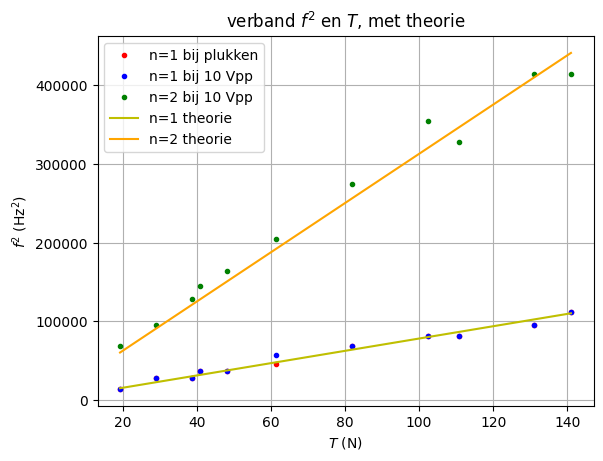

In [56]:
#metingen laatste dag, 14-09-2026

#spanning in N, uitgerekend met T=mg*constante (4-10)
T_N = np.array([141.0,131.0,110.9,102.36,81.87,61.41,48.30,40.94,38.76,28.98,19.32]) 
#frequentie van de grondtoon bij plukken, functiegenerator uit, in Hz
f_pluk = np.array([333.8,309.9,286.1,286.4,262.3,214.6,190.7,190.7,166.9,166.9,119.2]) 

#frequentie bij functiegenerator amplitude van 10Vpp, in Hz
f_grondtoon = np.array([333.8,309.9,286.1,286.1,262.3,238.4,190.7,190.7,166.9,166.9,119.2])
f_2 = np.array([643.7,643.7,572.2,596.0,524.5,453.0,405.3,381.5,357.6,309.9,262.3])

'''
we hebben al deze frequenties getest bij verschillende amplitudes, in tegenstelling tot de metingen van vorige week, is de 
frequentie bij elke amplitude gelijk, dus bij 3 Vpp, 5 Vpp, 7 Vpp en 10 Vpp, daarom gaan we de grafieken van de frequenties
bij verschillende amplitudes niet plotten. we gaan ervanuit dat de metingen van vandaag beter zijn dan die van vorige week,
omdat de resultaten op de oscilloscoop vrij constant waren in tegenstelling tot vorige week.
'''
#vergelijking snaartheorie in het kwadraat
def sn2(n,T):
    return (n**2)/(4*(L**2))*(T/mu)

T_th = np.linspace(min(T_N),max(T_N),200)


plt.figure()
plt.plot(T_N,f_pluk**2,'r.',label='n=1 bij plukken')
plt.plot(T_N,f_grondtoon**2,'b.',label='n=1 bij 10 Vpp')
plt.plot(T_N,f_2**2,'g.',label='n=2 bij 10 Vpp')
plt.plot(T_th,sn2(1,T_th),'y-',label='n=1 theorie')
plt.plot(T_th,sn2(2,T_th),color='orange',label='n=2 theorie')
plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$, met theorie')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()

erg positief over de plots, de metingen lijken goed te zijn en is er geen reden om nog opnieuw metingen te hoeven uitvoeren.

sigma_T = 0.4905 N
sigma_f = 0.05 Hz
n=1: a = 782.65 ± 17.07, R² = 0.9780
n=2: a = 3161.12 ± 66.56, R² = 0.9788


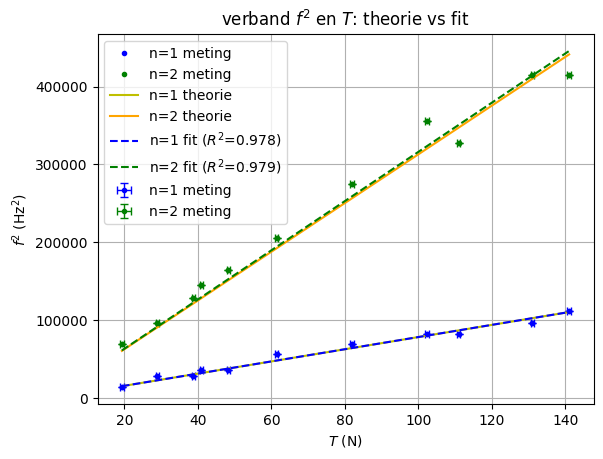

In [57]:
def lin_fit(T, a):
    return a * T
popt1,pcov1 = curve_fit(lin_fit, T_N, f_grondtoon**2)
popt2, pcov2 = curve_fit(lin_fit, T_N,f_2**2)

a1_err = np.sqrt(pcov1[0][0])
a2_err = np.sqrt(pcov2[0][0])

# --- onzekerheid op T ---
g = 9.81
sigma_m = 0.05      # kg, meetfout op de massa waarmee T bepaald is
constante = 1       # <-- pas aan als jullie een andere factor gebruikten
sigma_T = g * constante * sigma_m   # zelfde absolute fout voor elk punt
print(f"sigma_T = {sigma_T:.4f} N")

# --- onzekerheid op f, en propagatie naar f^2 ---
sigma_f = 0.05  # Hz

sigma_f2_grondtoon = 2 * f_grondtoon * sigma_f
sigma_f2_n2 = 2 * f_2 * sigma_f

print(f"sigma_f = {sigma_f} Hz")

#R^2 berekenen, hoe dichter bij 1, hoe beter de metingen zijn geweest
def r_squared(y_data, y_fit):
    residuals = y_data - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res/ss_tot

r2_1 = r_squared(f_grondtoon**2, lin_fit(T_N, *popt1))
r2_2 = r_squared(f_2**2, lin_fit(T_N, *popt2))

print(f"n=1: a = {popt1[0]:.2f} ± {a1_err:.2f}, R² = {r2_1:.4f}")
print(f"n=2: a = {popt2[0]:.2f} ± {a2_err:.2f}, R² = {r2_2:.4f}")

plt.figure()

# meetpunten met foutbalken
plt.errorbar(T_N, f_grondtoon**2, xerr=sigma_T, yerr=sigma_f2_grondtoon,
             fmt='b.', label='n=1 meting', capsize=3, elinewidth=1)
plt.errorbar(T_N, f_2**2, xerr=sigma_T, yerr=sigma_f2_n2,
             fmt='g.', label='n=2 meting', capsize=3, elinewidth=1)

plt.plot(T_N, f_grondtoon**2, 'b.', label='n=1 meting')
plt.plot(T_N, f_2**2, 'g.', label='n=2 meting')

plt.plot(T_th, sn2(1,T_th), 'y-', label='n=1 theorie')
plt.plot(T_th, sn2(2,T_th), color='orange', label='n=2 theorie')

plt.plot(T_th, lin_fit(T_th, *popt1), 'b--', label=f'n=1 fit ($R^2$={r2_1:.3f})')
plt.plot(T_th, lin_fit(T_th, *popt2), 'g--', label=f'n=2 fit ($R^2$={r2_2:.3f})')

plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$: theorie vs fit')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()



R^2 waardes zijn hoger dat die van de metingen van vorige week, dus gebruiken we deze metingen voor het beantwoorden van de onderzoeksvraag. ook zien de fits er goed uit en lijkt het overeen te komen met de theorie.

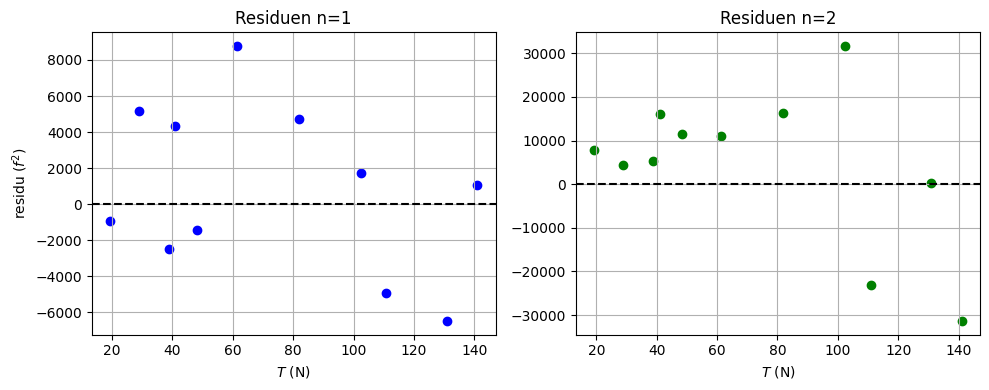

In [58]:
#residu plots
res1 = f_grondtoon**2 - lin_fit(T_N, *popt1)
res2 = f_2**2 - lin_fit(T_N, *popt2)

fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].scatter(T_N, res1, color='blue')
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_title('Residuen n=1')
axs[0].set_xlabel('$T$ (N)')
axs[0].set_ylabel('residu ($f^2$)')
axs[0].grid()

axs[1].scatter(T_N, res2, color='green')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title('Residuen n=2')
axs[1].set_xlabel('$T$ (N)')
axs[1].grid()

plt.tight_layout()
plt.show()

uit de grafiek van de residuen bij n=1 blijkt dat er geen systematische fout in zit. de punten liggen willekeurig verspreid over de grafiek. het patroon van de residuen van n=2 wijst wel op een systematische fout. De punten liggen bijna allemaal boven 0. Dit kan een fysische verklaring hebben, zoals de rek van de snaar bijv. Moeten we nog over twisten. we gaan een nieuwe fit proberen, dit keer in de vorm van y=ax+b ipv y=ax

=== n=2: simpele fit (door oorsprong) ===
a = 3161.12 ± 66.56, R² = 0.9788

=== n=2: fit met intercept ===
a = 2959.45 ± 122.49
b = 19298.19 ± 10249.46
R² = 0.9848

-> b wijkt niet significant af van 0


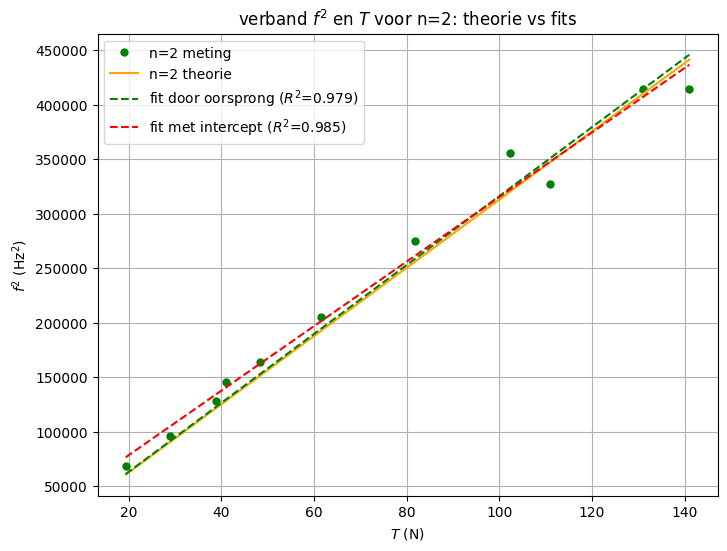

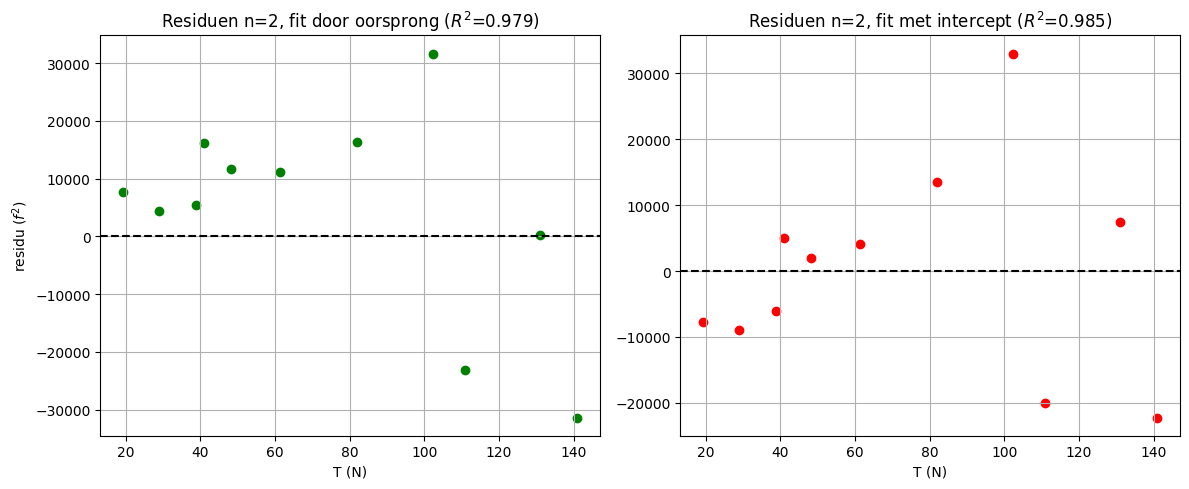

In [59]:
# --- modellen ---
def lin_fit(T, a):
    return a * T

def lin_fit_b(T, a, b):
    return a * T + b

# --- R^2 functie ---
def r_squared(y_data, y_fit):
    residuals = y_data - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res/ss_tot

# --- fits voor n=2 ---
popt2, pcov2 = curve_fit(lin_fit, T_N, f_2**2)
popt2b, pcov2b = curve_fit(lin_fit_b, T_N, f_2**2)

a2_err = np.sqrt(pcov2[0][0])
a2b_err = np.sqrt(pcov2b[0][0])
b2_err = np.sqrt(pcov2b[1][1])

r2_2 = r_squared(f_2**2, lin_fit(T_N, *popt2))
r2_2b = r_squared(f_2**2, lin_fit_b(T_N, *popt2b))

print("=== n=2: simpele fit (door oorsprong) ===")
print(f"a = {popt2[0]:.2f} ± {a2_err:.2f}, R² = {r2_2:.4f}")

print("\n=== n=2: fit met intercept ===")
print(f"a = {popt2b[0]:.2f} ± {a2b_err:.2f}")
print(f"b = {popt2b[1]:.2f} ± {b2_err:.2f}")
print(f"R² = {r2_2b:.4f}")

# check of b significant afwijkt van 0
if abs(popt2b[1]) > 2*b2_err:
    print(f"\n-> b wijkt significant af van 0 (|b| > 2*sigma_b), wijst op systematisch effect")
else:
    print(f"\n-> b wijkt niet significant af van 0")

# --- hoofdgrafiek: theorie, beide fits, meetpunten ---
plt.figure(figsize=(8,6))
plt.plot(T_N, f_2**2, 'g.', markersize=10, label='n=2 meting')
plt.plot(T_th, sn2(2, T_th), color='orange', label='n=2 theorie')
plt.plot(T_th, lin_fit(T_th, *popt2), 'g--', label=f'fit door oorsprong ($R^2$={r2_2:.3f})')
plt.plot(T_th, lin_fit_b(T_th, *popt2b), 'r--', label=f'fit met intercept ($R^2$={r2_2b:.3f})')

plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$ voor n=2: theorie vs fits')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()

# --- residuanalyse voor beide fits ---
res2_simple = f_2**2 - lin_fit(T_N, *popt2)
res2_b = f_2**2 - lin_fit_b(T_N, *popt2b)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].scatter(T_N, res2_simple, color='green')
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_title(f'Residuen n=2, fit door oorsprong ($R^2$={r2_2:.3f})')
axs[0].set_xlabel('T (N)')
axs[0].set_ylabel('residu ($f^2$)')
axs[0].grid()

axs[1].scatter(T_N, res2_b, color='red')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title(f'Residuen n=2, fit met intercept ($R^2$={r2_2b:.3f})')
axs[1].set_xlabel('T (N)')
axs[1].grid()

plt.tight_layout()
plt.show()

De R^2 waarde gaat maar marginaal omhoog, met 0.006. En de meetfout van b is enorm, meer dan 50%. De residuen zijn gewoon omlaag verplaatst en liggen niet perse mooi rondom 0. het patroon is gewoon verschoven. we proberen nu een ander verband, namelijk aT+cT^2. 

=== n=2: simpele fit (door oorsprong) ===
a = 3161.12 ± 66.56, R² = 0.9788

=== n=2: fit met intercept ===
a = 2959.45 ± 122.49
b = 19298.19 ± 10249.46
R² = 0.9848

=== n=2: kwadratische fit (a*T + c*T^2) ===
a = 3686.22 ± 185.52
c = -4.7360 ± 1.6110
R² = 0.9892
-> c wijkt significant af van 0, wijst op niet-lineair effect


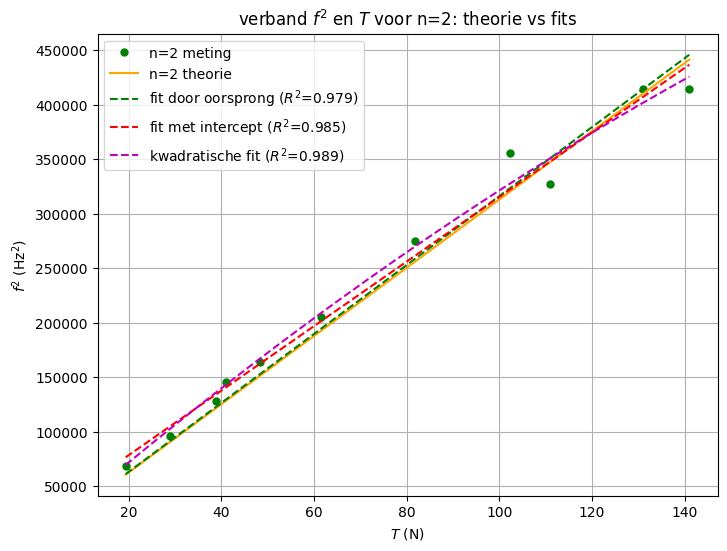

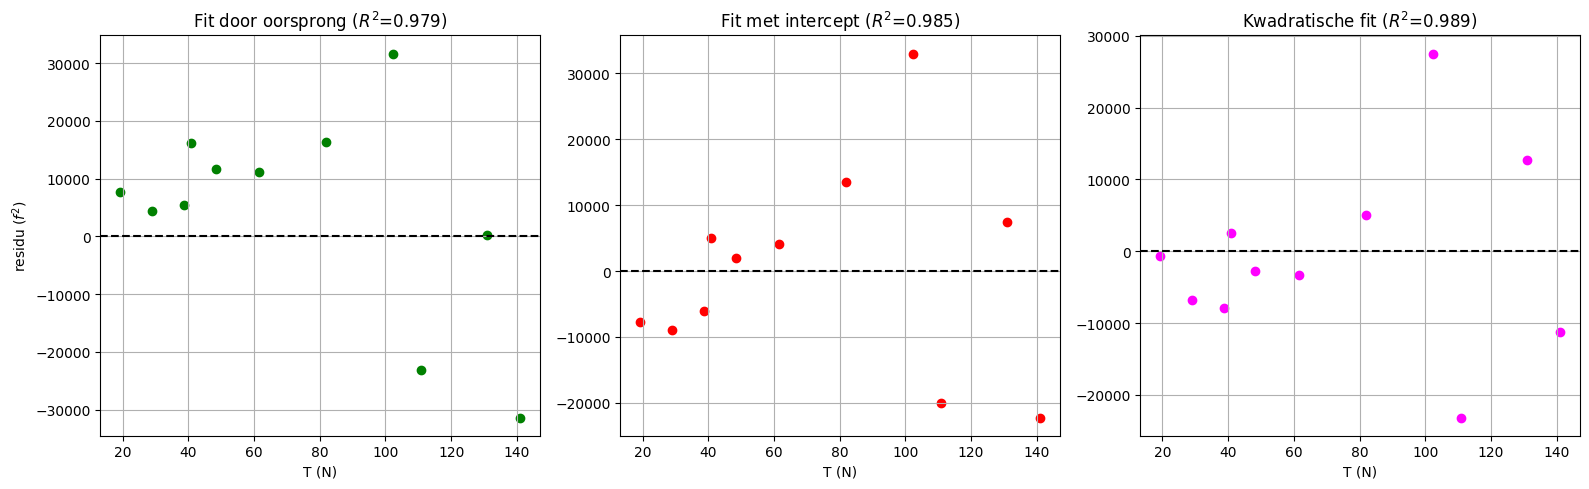

In [60]:
# --- modellen ---
def lin_fit(T, a):
    return a * T

def lin_fit_b(T, a, b):
    return a * T + b

def quad_fit(T, a, c):
    return a * T + c * T**2

# --- R^2 functie ---
def r_squared(y_data, y_fit):
    residuals = y_data - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res/ss_tot

# --- fits voor n=2 ---
popt2, pcov2 = curve_fit(lin_fit, T_N, f_2**2)
popt2b, pcov2b = curve_fit(lin_fit_b, T_N, f_2**2)
popt2c, pcov2c = curve_fit(quad_fit, T_N, f_2**2)

a2_err = np.sqrt(pcov2[0][0])
a2b_err = np.sqrt(pcov2b[0][0])
b2_err = np.sqrt(pcov2b[1][1])
a2c_err = np.sqrt(pcov2c[0][0])
c2_err = np.sqrt(pcov2c[1][1])

r2_2 = r_squared(f_2**2, lin_fit(T_N, *popt2))
r2_2b = r_squared(f_2**2, lin_fit_b(T_N, *popt2b))
r2_2c = r_squared(f_2**2, quad_fit(T_N, *popt2c))

print("=== n=2: simpele fit (door oorsprong) ===")
print(f"a = {popt2[0]:.2f} ± {a2_err:.2f}, R² = {r2_2:.4f}")

print("\n=== n=2: fit met intercept ===")
print(f"a = {popt2b[0]:.2f} ± {a2b_err:.2f}")
print(f"b = {popt2b[1]:.2f} ± {b2_err:.2f}")
print(f"R² = {r2_2b:.4f}")

print("\n=== n=2: kwadratische fit (a*T + c*T^2) ===")
print(f"a = {popt2c[0]:.2f} ± {a2c_err:.2f}")
print(f"c = {popt2c[1]:.4f} ± {c2_err:.4f}")
print(f"R² = {r2_2c:.4f}")

if abs(popt2c[1]) > 2*c2_err:
    print("-> c wijkt significant af van 0, wijst op niet-lineair effect")
else:
    print("-> c wijkt niet significant af van 0")

# --- hoofdgrafiek: theorie, alle drie fits, meetpunten ---
plt.figure(figsize=(8,6))
plt.plot(T_N, f_2**2, 'g.', markersize=10, label='n=2 meting')
plt.plot(T_th, sn2(2, T_th), color='orange', label='n=2 theorie')
plt.plot(T_th, lin_fit(T_th, *popt2), 'g--', label=f'fit door oorsprong ($R^2$={r2_2:.3f})')
plt.plot(T_th, lin_fit_b(T_th, *popt2b), 'r--', label=f'fit met intercept ($R^2$={r2_2b:.3f})')
plt.plot(T_th, quad_fit(T_th, *popt2c), 'm--', label=f'kwadratische fit ($R^2$={r2_2c:.3f})')

plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$ voor n=2: theorie vs fits')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()

# --- residuanalyse voor alle drie de fits ---
res2_simple = f_2**2 - lin_fit(T_N, *popt2)
res2_b = f_2**2 - lin_fit_b(T_N, *popt2b)
res2_c = f_2**2 - quad_fit(T_N, *popt2c)

fig, axs = plt.subplots(1, 3, figsize=(16,5))

axs[0].scatter(T_N, res2_simple, color='green')
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_title(f'Fit door oorsprong ($R^2$={r2_2:.3f})')
axs[0].set_xlabel('T (N)')
axs[0].set_ylabel('residu ($f^2$)')
axs[0].grid()

axs[1].scatter(T_N, res2_b, color='red')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title(f'Fit met intercept ($R^2$={r2_2b:.3f})')
axs[1].set_xlabel('T (N)')
axs[1].grid()

axs[2].scatter(T_N, res2_c, color='magenta')
axs[2].axhline(0, color='black', linestyle='--')
axs[2].set_title(f'Kwadratische fit ($R^2$={r2_2c:.3f})')
axs[2].set_xlabel('T (N)')
axs[2].grid()

plt.tight_layout()
plt.show()

voor de kwadratische fit is de R^2 wel gestegen, met 0.0104. ook is de kwadratische term c significant, met een acceptabele fout. er zit wel degelijk een niet-lineaire term in de metingen. de metingen tussen de 20-90 T liggen mooi om 0, maar bij de metingen van T>100 zijn er heftige uitschieters. we gaan nog een keer een plot maken om te kijken of deze punten gewoon meetfouten zijn en dat er dus geen niet-lineair verband is, of dat ze er wel bij horen. 

Punten in volledige dataset: 11
Punten na verwijderen uitschieters: 9

=== Fit met alle punten ===
a = 3161.12 ± 66.56, R² = 0.9788

=== Fit zonder T≈102 en T≈111 ===
a = 3148.75 ± 65.59, R² = 0.9860


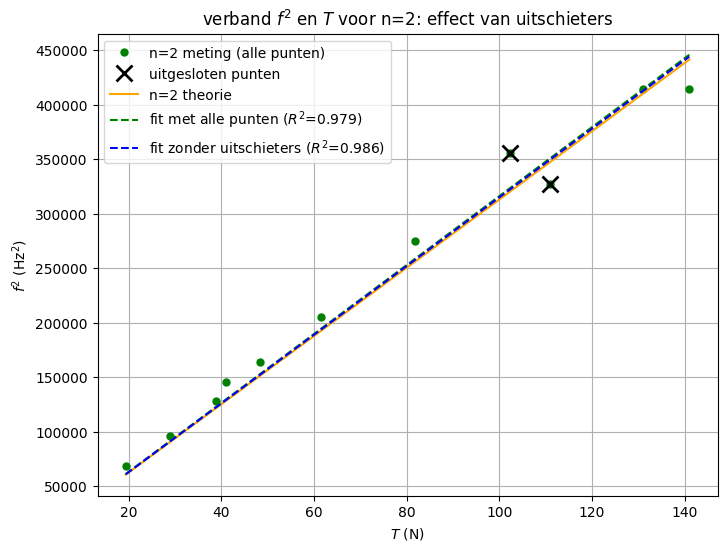

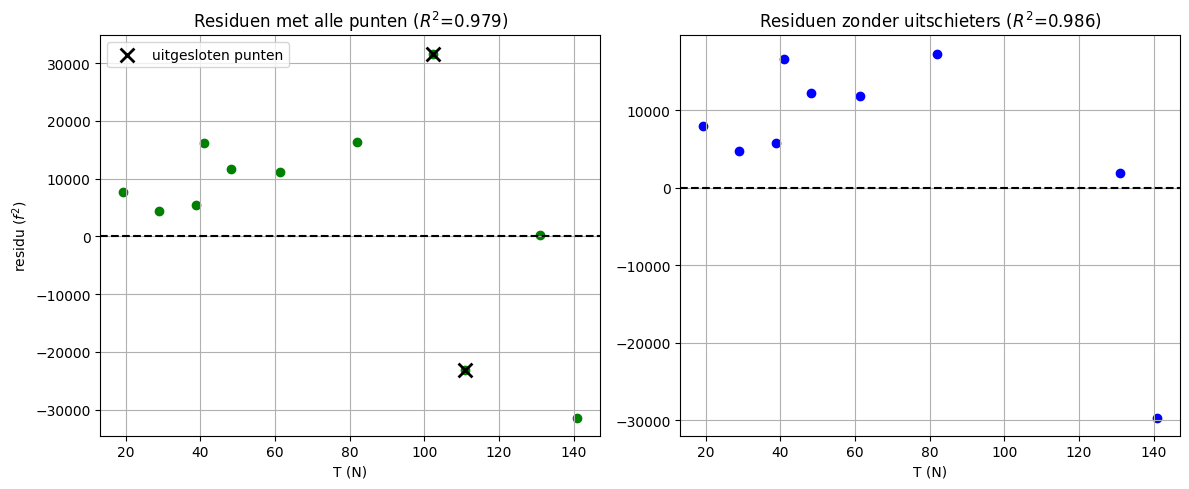

In [61]:
def lin_fit(T, a):
    return a * T

def r_squared(y_data, y_fit):
    residuals = y_data - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res/ss_tot

# --- masker om de twee verdachte punten (T≈102 en T≈111) uit te sluiten ---
mask = ~np.isclose(T_N, 102.36) & ~np.isclose(T_N, 110.9)

T_N_clean = T_N[mask]
f_2_clean = f_2[mask]

print(f"Punten in volledige dataset: {len(T_N)}")
print(f"Punten na verwijderen uitschieters: {len(T_N_clean)}")

# --- fit MET alle punten ---
popt_all, pcov_all = curve_fit(lin_fit, T_N, f_2**2)
a_all_err = np.sqrt(pcov_all[0][0])
r2_all = r_squared(f_2**2, lin_fit(T_N, *popt_all))

# --- fit ZONDER de twee uitschieters ---
popt_clean, pcov_clean = curve_fit(lin_fit, T_N_clean, f_2_clean**2)
a_clean_err = np.sqrt(pcov_clean[0][0])
r2_clean = r_squared(f_2_clean**2, lin_fit(T_N_clean, *popt_clean))

print("\n=== Fit met alle punten ===")
print(f"a = {popt_all[0]:.2f} ± {a_all_err:.2f}, R² = {r2_all:.4f}")

print("\n=== Fit zonder T≈102 en T≈111 ===")
print(f"a = {popt_clean[0]:.2f} ± {a_clean_err:.2f}, R² = {r2_clean:.4f}")

# --- residuen voor beide gevallen ---
res_all = f_2**2 - lin_fit(T_N, *popt_all)
res_clean = f_2_clean**2 - lin_fit(T_N_clean, *popt_clean)

# --- hoofdgrafiek ---
plt.figure(figsize=(8,6))
plt.plot(T_N, f_2**2, 'g.', markersize=10, label='n=2 meting (alle punten)')
plt.plot(T_N[~mask], f_2[~mask]**2, 'kx', markersize=12, markeredgewidth=2, label='uitgesloten punten')
plt.plot(T_th, sn2(2, T_th), color='orange', label='n=2 theorie')
plt.plot(T_th, lin_fit(T_th, *popt_all), 'g--', label=f'fit met alle punten ($R^2$={r2_all:.3f})')
plt.plot(T_th, lin_fit(T_th, *popt_clean), 'b--', label=f'fit zonder uitschieters ($R^2$={r2_clean:.3f})')

plt.grid()
plt.legend()
plt.title('verband $f^2$ en $T$ voor n=2: effect van uitschieters')
plt.xlabel('$T$ (N)')
plt.ylabel('$f^2$ (Hz$^2$)')
plt.show()

# --- residuplots naast elkaar ---
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].scatter(T_N, res_all, color='green')
axs[0].scatter(T_N[~mask], res_all[~mask], color='black', marker='x', s=100, linewidths=2, label='uitgesloten punten')
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_title(f'Residuen met alle punten ($R^2$={r2_all:.3f})')
axs[0].set_xlabel('T (N)')
axs[0].set_ylabel('residu ($f^2$)')
axs[0].legend()
axs[0].grid()

axs[1].scatter(T_N_clean, res_clean, color='blue')
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_title(f'Residuen zonder uitschieters ($R^2$={r2_clean:.3f})')
axs[1].set_xlabel('T (N)')
axs[1].grid()

plt.tight_layout()
plt.show()

de twee uitschieters hebben dus nauwelijks invloed op de uitkomst van de fit. dit is positief voor ons onderzoek: de metingen die dus wel op de lijn liggen hebben dus een sterk lineair verband. deze uitschieters zijn dus waarschijnlijk foutieve metingen. we houden ons gewoon aan de originele fitlijn, de eerste, voor n=2. we behouden dus ook deze punten in de hoofdanalyse. 